In [1]:
# import the pandas library
import pandas as pd

In [2]:
# Exchange Rate Dataframe
ex = pd.read_csv("data/DEXUSEU.csv")
ex = ex[ex['observation_date'].between('1991-01-01', '2023-01-01')]
ex.set_index('observation_date', inplace=True)
ex.head()

,DEXUSEU
observation_date,
1999-01-01,1.0653
2000-01-01,0.9232
2001-01-01,0.8952
2002-01-01,0.9454
2003-01-01,1.1321


In [3]:
# Germany 1-Year Bond Yield
gb = pd.read_csv("data/IRLTCT01DEM156N.csv")
gb = gb[gb['observation_date'].between('1999-01-01', '2023-01-01')]
gb.set_index('observation_date', inplace=True)
gb.head()

,IRLTCT01DEM156N
observation_date,
1999-01-01,4.490610
2000-01-01,5.263959
2001-01-01,4.796593
2002-01-01,4.783580
2003-01-01,4.071143


In [4]:
# US 1-Year Bond Yield
ub = pd.read_csv("data/DGS1.csv")
ub = ub[ub['observation_date'].between('1999-01-01', '2023-01-01')]
ub.set_index('observation_date', inplace=True)
ub.head()

,DGS1
observation_date,
1999-01-01,5.08
2000-01-01,6.11
2001-01-01,3.49
2002-01-01,2.00
2003-01-01,1.24


In [5]:
df = pd.DataFrame()
df['observation_date'] = ex.index.values
df['exchange_rate'] = ex.values
df['germany_yield'] = gb.values
df['us_yield'] = ub.values
df.head()

,observation_date,exchange_rate,germany_yield,us_yield
0,1999-01-01,1.0653,4.490610,5.08
1,2000-01-01,0.9232,5.263959,6.11
2,2001-01-01,0.8952,4.796593,3.49
3,2002-01-01,0.9454,4.783580,2.00
4,2003-01-01,1.1321,4.071143,1.24


In [6]:
import datetime
df['observation_date'] = pd.to_datetime(df['observation_date'])
df['year'] = df['observation_date'].dt.year

In [7]:
df.describe()

,observation_date,exchange_rate,germany_yield,us_yield,year
count,25,25.000000,25.000000,25.000000,25.000000
mean,2011-01-01 02:52:48,1.188536,2.372267,2.039200,2011.000000
min,1999-01-01 00:00:00,0.895200,-0.511024,0.100000,1999.000000
25%,2005-01-01 00:00:00,1.107200,0.495194,0.320000,2005.000000
50%,2011-01-01 00:00:00,1.181700,2.609185,1.830000,2011.000000
75%,2017-01-01 00:00:00,1.326100,4.037156,3.490000,2017.000000
max,2023-01-01 00:00:00,1.472600,5.263959,6.110000,2023.000000
std,NaN,0.153229,1.870986,1.910528,7.359801


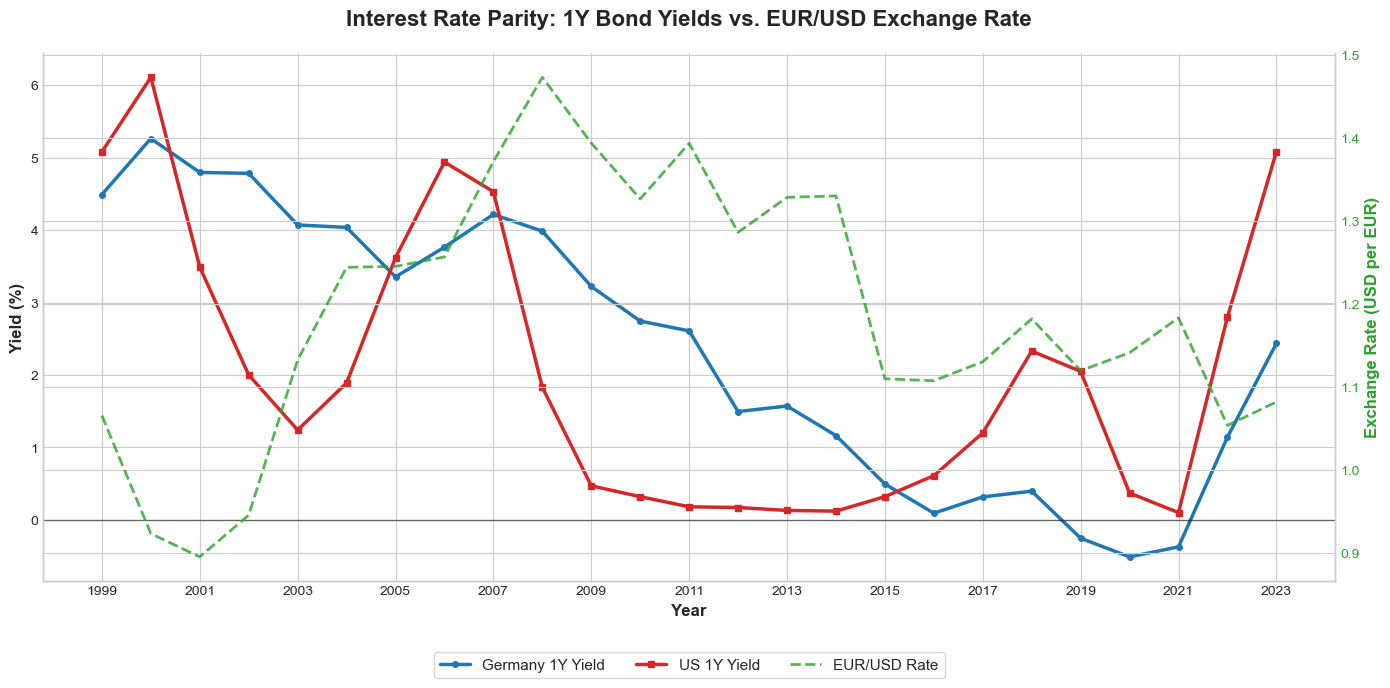

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Use a clean style
plt.style.use('seaborn-v0_8-whitegrid') 

fig, ax1 = plt.subplots(figsize=(14, 7))

# --- Left Axis: Yields ---
# Plotting with markers to make the data points clearer
ax1.plot(df['year'], df['germany_yield'], label='Germany 1Y Yield', 
         color='#1f77b4', linewidth=2.5, marker='o', markersize=4)
ax1.plot(df['year'], df['us_yield'], label='US 1Y Yield', 
         color='#d62728', linewidth=2.5, marker='s', markersize=4)

# Add a horizontal line at 0% to highlight negative German yields
ax1.axhline(0, color='black', linewidth=1, linestyle='-', alpha=0.5)

ax1.set_xlabel('Year', fontsize=12, fontweight='bold')
ax1.set_ylabel('Yield (%)', fontsize=12, fontweight='bold')
ax1.tick_params(axis='both', which='major', labelsize=10)

# Force the x-axis to show every 2nd year to avoid overlapping
plt.xticks(np.arange(min(df['year']), max(df['year'])+1, 2))

# --- Right Axis: Exchange Rate ---
ax2 = ax1.twinx()
ax2.plot(df['year'], df['exchange_rate'], label='EUR/USD Rate', 
         color='#2ca02c', linestyle='--', linewidth=2, alpha=0.8)

ax2.set_ylabel('Exchange Rate (USD per EUR)', fontsize=12, fontweight='bold', color='#2ca02c')
ax2.tick_params(axis='y', labelcolor='#2ca02c')

# Remove the box frame for a modern look
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

# --- Title and Legend ---
plt.title('Interest Rate Parity: 1Y Bond Yields vs. EUR/USD Exchange Rate', 
          fontsize=16, fontweight='bold', pad=20)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center', 
           bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=True, fontsize=11)

plt.tight_layout()
plt.show()

In [9]:
(- df['us_yield'] + df['germany_yield']).corr(df['exchange_rate'])

0.3668126195541324

In [19]:
df['id'] = df['us_yield'] / 100
df['if'] = df['germany_yield'] / 100
df['expected_exchange_rate'] = ((1 + df['us_yield'] / 100) / (1 + df['germany_yield']/ 100) * df['exchange_rate']).shift(1)

# Calculate the expectation error (Actual - Expected)
df['expectation_error'] = df['exchange_rate'] - df['expected_exchange_rate']

In [20]:
df['expectation_error'].describe()

count    24.000000
mean      0.006670
std       0.094428
min      -0.206385
25%      -0.038711
50%       0.014101
75%       0.059582
max       0.211815
Name: expectation_error, dtype: float64

In [11]:
df.head()

,observation_date,exchange_rate,germany_yield,us_yield,year,id,if,expected_exchange_rate
0,1999-01-01,1.0653,4.490610,5.08,1999,0.0508,0.044906,NaN
1,2000-01-01,0.9232,5.263959,6.11,2000,0.0611,0.052640,1.071309
2,2001-01-01,0.8952,4.796593,3.49,2001,0.0349,0.047966,0.930620
3,2002-01-01,0.9454,4.783580,2.00,2002,0.0200,0.047836,0.884039
4,2003-01-01,1.1321,4.071143,1.24,2003,0.0124,0.040711,0.920285


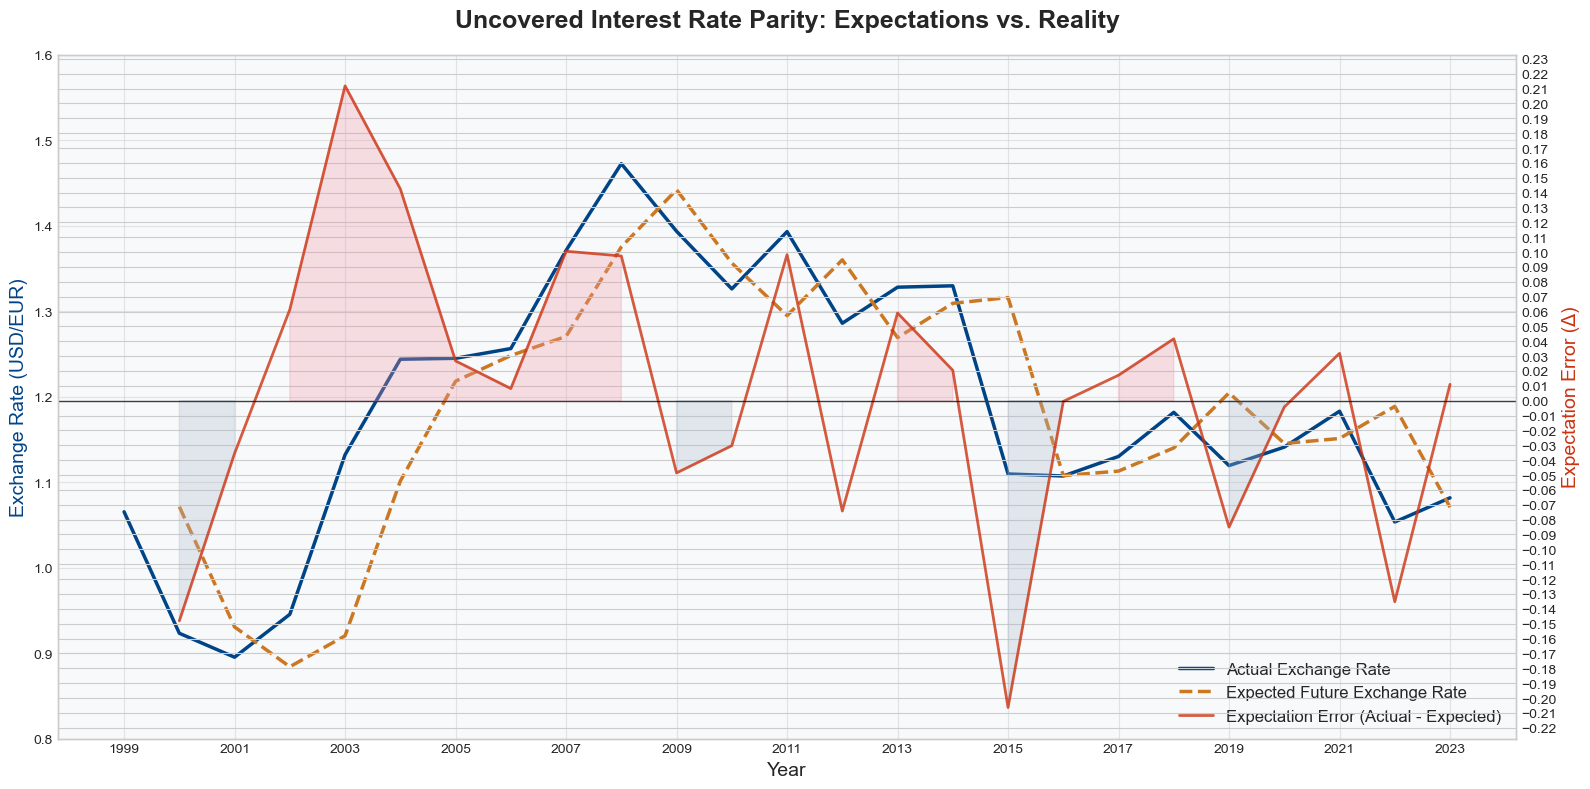

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np


# 2. Setup a single plot
fig, ax1 = plt.subplots(figsize=(16, 8))
plt.title('Uncovered Interest Rate Parity: Expectations vs. Reality', fontsize=18, fontweight='bold', pad=20)

# --- Primary Y-Axis (Left): Exchange Rates ---
# Plot actual and expected on the left axis
line1 = ax1.plot(df['year'], df['exchange_rate'], label="Actual Exchange Rate", color='#004488', linewidth=2.5)
line2 = ax1.plot(df['year'], df['expected_exchange_rate'], label="Expected Future Exchange Rate", color='#CC7722', linestyle='--', linewidth=2.5)

ax1.set_xlabel('Year', fontsize=14)
ax1.set_ylabel('Exchange Rate (USD/EUR)', fontsize=14, color='#004488')
ax1.set_yticks(np.arange(0.8, 1.7, 0.1)) 
ax1.set_xticks(range(1999, 2024, 2))
ax1.grid(True, alpha=0.5)

# --- Secondary Y-Axis (Right): Expectation Error (Difference) ---
ax2 = ax1.twinx()  # Create a second y-axis that shares the same x-axis

# Plot the difference on the right axis
line3 = ax2.plot(df['year'], df['expectation_error'], label="Expectation Error (Actual - Expected)", color='#CC3311', linewidth=2, alpha=0.8)

# Add a zero baseline for the difference reference
ax2.axhline(0, color='black', linewidth=1, linestyle='-', alpha=0.7)

# Fill colors for the error to make it pop (optional, but looks great)
ax2.fill_between(df['year'], 0, df['expectation_error'], where=(df['expectation_error'] > 0), color='#EE99AA', alpha=0.3)
ax2.fill_between(df['year'], 0, df['expectation_error'], where=(df['expectation_error'] <= 0), color='#AABBCC', alpha=0.3)

ax2.set_ylabel('Expectation Error (Δ)', fontsize=14, color='#CC3311')
ax2.yaxis.set_major_locator(ticker.MultipleLocator(0.01))

# --- Combine Legends ---
# Since we have two axes, we need to gather the lines from both to make a single legend
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='lower right', fontsize=12)

# Render the chart
plt.xticks(rotation=45)
ax1.set_facecolor('#F8F9FA')
plt.tight_layout()
plt.show()

In [13]:
# Investing 1$ in Germany vs US
df['dollar_yield_us'] = 1 + df['us_yield']/100
df.head()

,observation_date,exchange_rate,germany_yield,us_yield,year,id,if,expected_exchange_rate,expectation_error,dollar_yield_us
0,1999-01-01,1.0653,4.490610,5.08,1999,0.0508,0.044906,NaN,NaN,1.0508
1,2000-01-01,0.9232,5.263959,6.11,2000,0.0611,0.052640,1.071309,-0.148109,1.0611
2,2001-01-01,0.8952,4.796593,3.49,2001,0.0349,0.047966,0.930620,-0.035420,1.0349
3,2002-01-01,0.9454,4.783580,2.00,2002,0.0200,0.047836,0.884039,0.061361,1.0200
4,2003-01-01,1.1321,4.071143,1.24,2003,0.0124,0.040711,0.920285,0.211815,1.0124
